In [ ]:
#1.修改前處理圖片儲存x的.h5的字典，x_train->x

In [1]:
import os
import h5py as h5
import numpy as np
import tensorflow as tf
from keras import layers,metrics
from keras.layers import Dropout,Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from keras.models import Model, load_model,Sequential
from keras.preprocessing import image
from keras.utils import layer_utils
from keras.utils.data_utils import get_file
from keras.applications.imagenet_utils import preprocess_input
from IPython.display import SVG
from matplotlib.pyplot import imshow
import scipy.io
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras
from keras.callbacks import EarlyStopping,ModelCheckpoint
from keras.optimizers import SGD,RMSprop,Adagrad,Adadelta,Adamax


Using TensorFlow backend.


In [2]:
#這是用於測試集

##輸入模型與檔案名稱，count是map的range，看預測
def Predict_SeriesLabel(model,name,count):
    with h5.File("D:/DLmidterm/"+str(name)+'.h5','r') as file:
        x_test=file.get("x").value/255
    data=scipy.io.loadmat("D:/DLmidterm/"+str(name)+".mat")
    y_test,y_onehot=data['y'],data['y_onehot']
    y_onehot=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    img=x_test[count]
    x = np.expand_dims(img,axis=0)
    x = np.argmax(model.predict(x),axis=2)
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    pdt=[datasheet[str(i[0])]for i in x] #預測為['A','B','C','D']
    arr=np.uint8(np.zeros((4,1)))
    for i in range(4):
        arr[i]=(np.argmax(y_onehot[count][i]))  
    ans=[datasheet[str(i[0])]for i in arr] #答案為['A','B','C','D']
#     if count <=40:
#         print("number ",count)
#         print("prdict=",pdt)
#         print("answer=",ans)
    fouracc=0
    imgacc=0
    for ind,letter in enumerate(pdt):
        if letter==ans[ind]:
            fouracc+=1
        else:
            plt.imshow(img)
            print("number ",count)
            print("prdict=",pdt)
            print("answer=",ans)
            plt.show()
    if pdt==ans:
            imgacc=1
    return x_test,imgacc,fouracc
    
def TestData(model,name):
    with h5.File("D:/DLmidterm/"+str(name)+".h5",'r') as file:
        x_test=file.get("x").value/255
    data=scipy.io.loadmat("D:/DLmidterm/"+str(name)+".mat")
    y_test,y_onehot=data['y'],data['y_onehot']
    y_onehot=y_onehot.reshape((int(y_onehot.shape[0]/4),4,19))
    for i in range(40):
        Predict_Label(model,x_test[i],i,y_onehot)
    return x_test,y_onehot

def Predict_Label(model,image,num,y_onehot):
    x = np.expand_dims(image,axis=0)
    x=np.argmax(model.predict(x),axis=2)
    pdt=LabelToLetter(x)
    ans=Answer(num,y_onehot)
    fouracc=0
    for ind,letter in enumerate(pdt):
        if letter!=ans[ind]:
            fouracc+=1
    print("prdict=",pdt)
    print("answer=",ans)
    print("wrong words=",fouracc)
    plt.imshow(image)
    plt.show()

#輸入測試第幾張圖片，得到圖片解答是麼
def Answer(num,y_onehot):
    arr=np.uint8(np.zeros((4,1)))
    for i in range(4):
        arr[i]=np.argmax(y_onehot[num][i])  
    ans=LabelToLetter(arr)
    return ans
#轉換標籤
def LabelToLetter(data):
    datasheet={"0":"2","1":"3","2":"4","3":'5',"4":'7',"5":'9',"6":'A',"7":'C',"8":'F',"9":'H',"10":'K',"11":'M',"12":'N',"13":'P',"14":'Q',"15":'R',"16":'T',"17":'Y',"18":'Z'}
    letter=[datasheet[str(i[0])]for i in data]
    return letter
        
# x = np.expand_dims(X_train[5],axis=0)
# x=np.argmax(model.predict(x),axis=2)
# print(LabelToLetter(x))
# imshow(X_train[5])
    
    

which file?owntest
prdict= ['2', '4', 'K', '2']
answer= ['2', '4', 'K', '2']
wrong words= 0


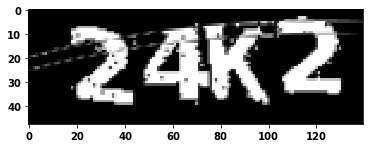

prdict= ['3', '4', 'F', 'M']
answer= ['3', '4', 'F', 'M']
wrong words= 0


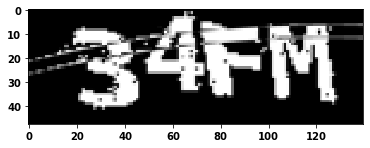

prdict= ['3', '5', 'Q', 'C']
answer= ['3', '9', 'Q', 'C']
wrong words= 1


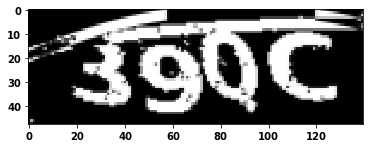

prdict= ['3', 'R', 'C', 'P']
answer= ['3', 'R', 'C', 'P']
wrong words= 0


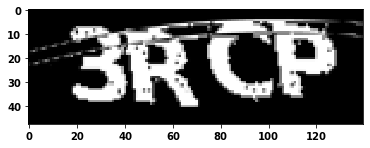

prdict= ['3', 'T', 'H', 'H']
answer= ['3', 'T', 'H', 'H']
wrong words= 0


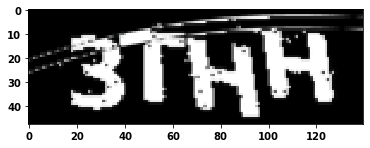

prdict= ['3', 'Z', '4', 'C']
answer= ['3', 'Z', '4', 'C']
wrong words= 0


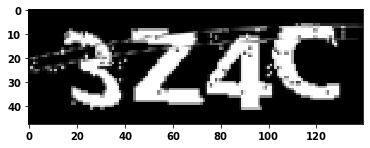

prdict= ['4', '4', 'Y', 'K']
answer= ['4', '4', 'Y', 'K']
wrong words= 0


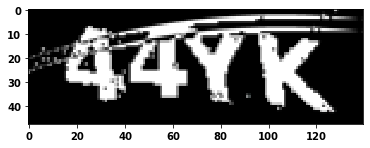

prdict= ['4', '9', 'P', 'M']
answer= ['4', '9', 'P', 'M']
wrong words= 0


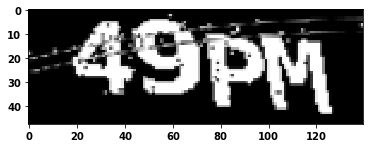

prdict= ['4', 'H', 'N', 'K']
answer= ['4', 'H', 'N', 'K']
wrong words= 0


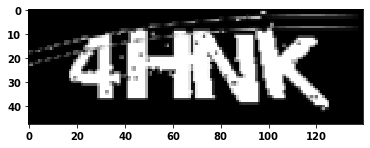

prdict= ['4', 'M', 'A', 'P']
answer= ['4', 'M', '3', 'P']
wrong words= 1


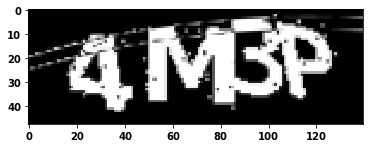

prdict= ['4', 'M', 'Y', '3']
answer= ['4', 'M', 'Y', '3']
wrong words= 0


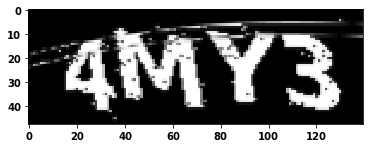

prdict= ['4', 'Y', 'Y', '3']
answer= ['4', 'Y', 'Y', '3']
wrong words= 0


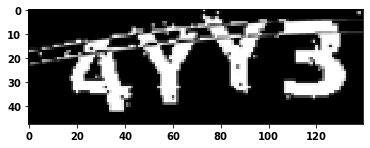

prdict= ['4', 'Z', '3', 'P']
answer= ['4', 'Z', '3', 'P']
wrong words= 0


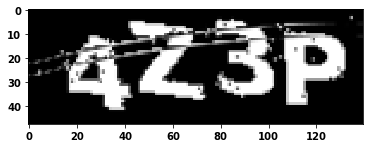

prdict= ['4', 'Z', 'N', 'C']
answer= ['4', 'Z', 'N', 'C']
wrong words= 0


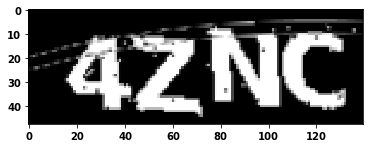

prdict= ['5', '2', 'Y', 'Q']
answer= ['5', '2', 'Y', 'Q']
wrong words= 0


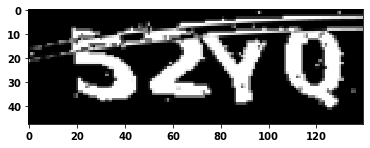

prdict= ['5', '4', 'T', 'H']
answer= ['5', '4', 'T', 'H']
wrong words= 0


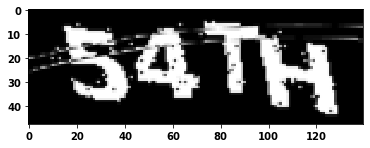

prdict= ['5', 'H', 'R', 'Q']
answer= ['5', 'H', 'R', 'Q']
wrong words= 0


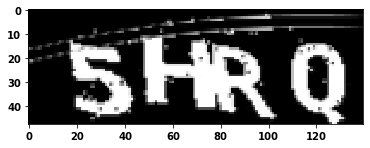

prdict= ['5', 'K', 'A', 'F']
answer= ['5', 'K', 'A', 'F']
wrong words= 0


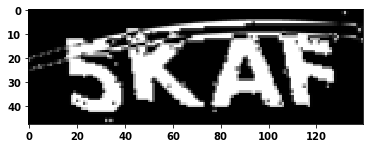

prdict= ['5', 'K', 'R', 'Z']
answer= ['5', 'K', 'R', 'Z']
wrong words= 0


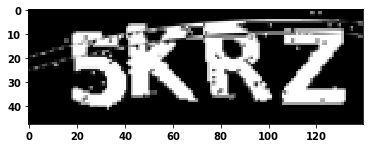

prdict= ['5', 'M', 'H', '3']
answer= ['5', 'M', 'H', '3']
wrong words= 0


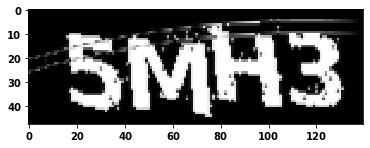

prdict= ['7', '7', 'A', 'C']
answer= ['7', '7', '4', 'C']
wrong words= 1


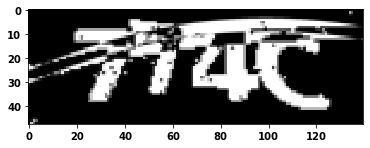

prdict= ['7', 'C', 'N', '7']
answer= ['7', 'C', 'N', '7']
wrong words= 0


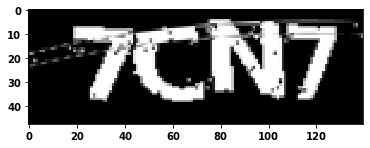

prdict= ['7', 'N', 'Y', '3']
answer= ['7', 'N', 'Y', '3']
wrong words= 0


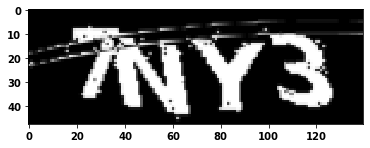

prdict= ['7', 'R', 'N', 'Z']
answer= ['7', 'R', 'N', 'Z']
wrong words= 0


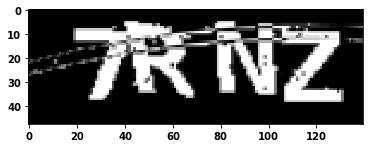

prdict= ['7', 'Y', 'C', 'P']
answer= ['7', 'Y', 'C', 'P']
wrong words= 0


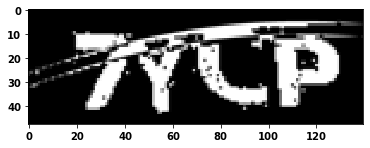

prdict= ['9', '3', '4', '2']
answer= ['9', '3', '4', '2']
wrong words= 0


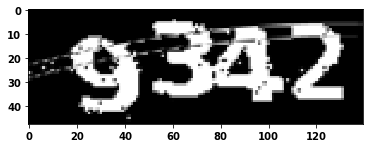

prdict= ['9', '5', '9', '2']
answer= ['9', '5', '9', '2']
wrong words= 0


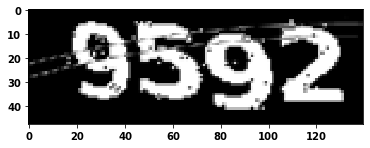

prdict= ['9', '9', '5', '4']
answer= ['9', '9', '5', '4']
wrong words= 0


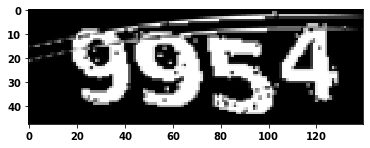

prdict= ['9', 'A', '7', 'A']
answer= ['9', 'A', '7', 'A']
wrong words= 0


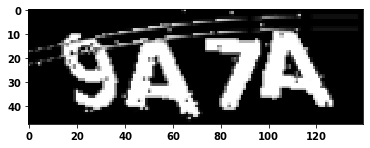

prdict= ['9', 'C', '3', 'C']
answer= ['9', 'C', '3', 'C']
wrong words= 0


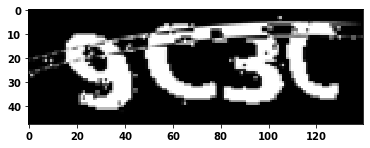

prdict= ['9', 'N', 'Q', 'F']
answer= ['9', 'N', 'Q', 'F']
wrong words= 0


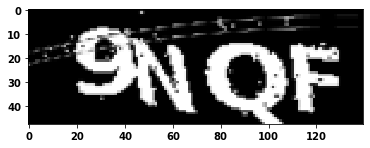

prdict= ['9', 'Z', 'F', '4']
answer= ['9', 'Z', 'F', '4']
wrong words= 0


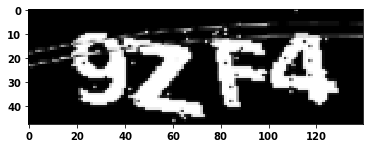

prdict= ['A', '2', 'H', 'Y']
answer= ['A', '2', 'H', 'Y']
wrong words= 0


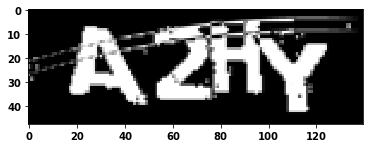

prdict= ['A', '3', 'K', 'N']
answer= ['A', '3', 'K', 'N']
wrong words= 0


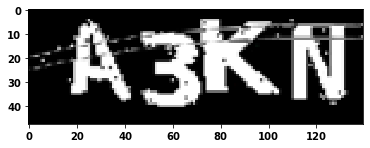

prdict= ['A', '5', 'Q', 'K']
answer= ['A', '5', 'C', 'K']
wrong words= 1


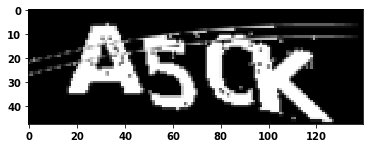

prdict= ['A', '7', 'H', 'M']
answer= ['A', '7', 'H', 'M']
wrong words= 0


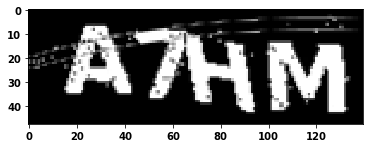

prdict= ['A', '9', 'R', 'Y']
answer= ['A', '9', 'R', 'Y']
wrong words= 0


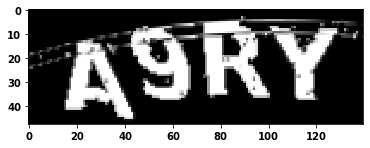

prdict= ['A', 'C', '7', 'F']
answer= ['A', 'C', '7', 'F']
wrong words= 0


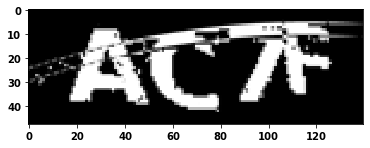

prdict= ['A', 'C', '7', 'Q']
answer= ['A', 'C', '7', 'Q']
wrong words= 0


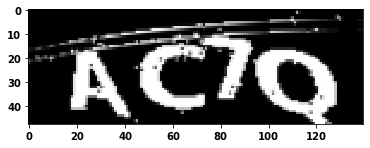

prdict= ['A', 'H', 'M', 'T']
answer= ['A', 'H', 'M', 'T']
wrong words= 0


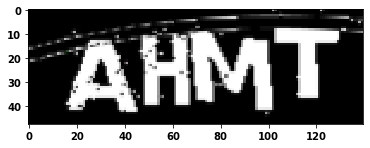

In [28]:
#測試前40張
filename=input("which file?")
x_test,y_onehot=TestData(model2,filename)

In [12]:
data=scipy.io.loadmat("D:/DLmidterm/owntest.mat")
x,y,y_onehot=data['x'],data['y'],data['y_onehot']
data1=scipy.io.loadmat("D:/DLmidterm/train.mat")
x1,y1,y1_onehot=data1['x'],data1['y'],data1['y_onehot']

In [13]:
with h5.File("D:/DLmidterm/owntest.h5",'r') as file:
        x=file.get("x").value
x.shape

(106, 48, 140, 3)

In [ ]:
#以下是訓練模型

In [3]:
def Read_TrainData():
    with h5.File("D:/DLmidterm/train.h5",'r') as file:
        x_train=file.get("x").value/255
    data=scipy.io.loadmat("train.mat")
    y_train,y_onehot=data['y'],data['y_onehot']
    y_onehot=y_onehot.reshape((5000,4,19))
    return x_train,y_onehot
def Validation_Data(x_train,y_onehot,ratio=0.25):
    X_train, X_test, y_train, y_test = train_test_split(x_train, y_onehot, test_size=ratio, random_state=1)
    return X_train, X_test, y_train, y_test

def Deal_With_Label(data): #將label轉成[array(第一碼),array(第二碼),array(第三碼),array(第四碼)]
    label=[]
    for num in range(4):
        data_array=np.zeros((data.shape[0],19))
        for i in range(data.shape[0]):
            data_array[i]=data[i][num]
        label.append(data_array)
    return label
x_train,y_onehot=Read_TrainData()
X_train, X_test, y_train, y_test=Validation_Data(x_train,y_onehot,0.25)

y_train=Deal_With_Label(y_train)
y_test=Deal_With_Label(y_test)
print(y_train[0])
print(y_test[0]) ##y_train[0]=[422T] y_test[0]=[C29T]

D:\anaconda\lib\site-packages\h5py\_hl\dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [4]:
def show_train_history(train_history,train1,train2,train3,train4 ):

    plt.plot(train_history.history[train1])

    plt.plot(train_history.history[train2])

    plt.plot(train_history.history[train3])
    
    plt.plot(train_history.history[train4])
    plt.title('Train History')

    plt.ylabel('train')

    plt.xlabel('Epoch')

    plt.legend(['train1','train2','train3','train4'], loc='upper left')

    plt.show()

#show_train_history(train_history, 'digit1_accuracy', 'digit2_accuracy','digit3_accuracy', 'digit4_accuracy')

which modelRMSprop-11-0.9952


D:\anaconda\lib\site-packages\h5py\_hl\dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


number  32
prdict= ['7', 'H', '4', 'C']
answer= ['7', '7', '4', 'C']


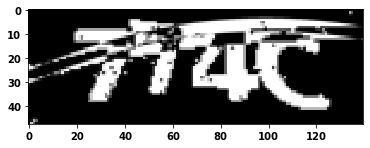

number  70
prdict= ['P', 'N', '3', '7']
answer= ['F', 'N', '3', '7']


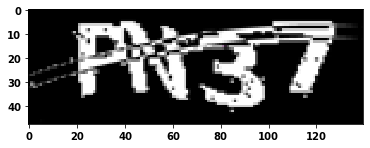

number  110
prdict= ['F', 'H', 'H', '9']
answer= ['P', 'H', 'H', '9']


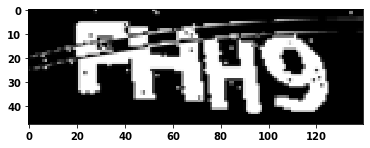

number  144
prdict= ['2', '9', 'N', 'Y']
answer= ['Z', '9', 'N', 'Y']


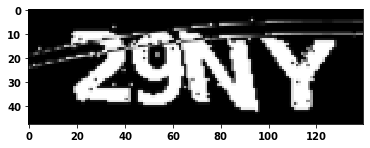

number  145
prdict= ['2', '9', 'T', 'M']
answer= ['Z', '9', 'T', 'M']


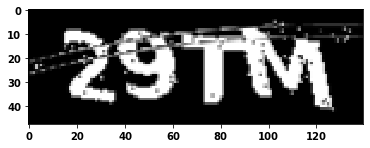

number  146
prdict= ['2', 'A', 'P', '3']
answer= ['Z', 'A', 'P', '3']


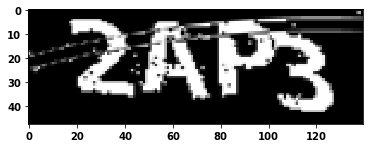

150 picture total wrong=6
one word accuracy= 0.99
four word accuracy= 0.96


In [8]:
def TestOwn():
    x=input("which model")
    model=load_model("D:/DLmidterm/checkpoint/"+x+".h5")
    filename='owntest'
    l=[]
    filenum=len(os.listdir('D:/DLmidterm/'+filename+'dealed'))
    for i in range(150):
        x,imacc,facc=Predict_SeriesLabel(model,filename,i)
        l.append((imacc,facc))
    accuracy=np.sum(np.asarray(l),axis=0)
    sigma=np.asarray(accuracy)
    imgaccuracy=sigma[0]/x.shape[0]
    fourwordccuracy=sigma[1]/(4*x.shape[0])
    print('%d picture total wrong=%d'%(x.shape[0],4*x.shape[0]-sigma[1]))
    print('one word accuracy=',fourwordccuracy)
    print('four word accuracy=',imgaccuracy)
TestOwn()

In [258]:
X_in=Input((48,140,3))
X=X_in
X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=AveragePooling2D(pool_size=(2,2))(X)
X=Flatten()(X)
X=[Dense(19, name='digit1', activation='softmax')(X),
              Dense(19, name='digit2', activation='softmax')(X),
              Dense(19, name='digit3', activation='softmax')(X),
              Dense(19, name='digit4', activation='softmax')(X)]
model=Model(inputs=X_in,outputs=X)
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
train_history=model.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=6)
model.save('D:/DLmidterm/WithoutDropout.h5')

Model: "model_29"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_32 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_89 (Conv2D)              (None, 48, 140, 8)   1952        input_32[0][0]                   
__________________________________________________________________________________________________
batch_normalization_86 (BatchNo (None, 48, 140, 8)   32          conv2d_89[0][0]                  
__________________________________________________________________________________________________
activation_86 (Activation)      (None, 48, 140, 8)   0           batch_normalization_86[0][0]     
___________________________________________________________________________________________

In [223]:
X_in=Input((48,140,3))
X=X_in
X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Dropout(0.1)(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Dropout(0.1)(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=AveragePooling2D(pool_size=(2,2))(X)
X=Flatten()(X)
X=[Dense(19, name='digit1', activation='softmax')(X),
              Dense(19, name='digit2', activation='softmax')(X),
              Dense(19, name='digit3', activation='softmax')(X),
              Dense(19, name='digit4', activation='softmax')(X)]
model1=Model(inputs=X_in,outputs=X)
model1.summary()
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
train_history=model1.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=6)

Model: "model_28"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_31 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_83 (Conv2D)              (None, 48, 140, 8)   1952        input_31[0][0]                   
__________________________________________________________________________________________________
batch_normalization_80 (BatchNo (None, 48, 140, 8)   32          conv2d_83[0][0]                  
__________________________________________________________________________________________________
activation_80 (Activation)      (None, 48, 140, 8)   0           batch_normalization_80[0][0]     
___________________________________________________________________________________________

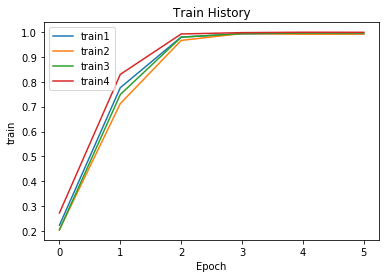

In [256]:
show_train_history(train_history, 'digit1_accuracy', 'digit2_accuracy','digit3_accuracy', 'digit4_accuracy')

In [1]:
show_train_history(train_history, 'val_digit1_accuracy', 'val_digit2_accuracy','val_digit3_accuracy', 'val_digit4_accuracy')

NameError: name 'show_train_history' is not defined

In [46]:
X_in=Input((48,140,3))
X=X_in
X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Dropout(0.1)(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X=Activation('relu')(X)
X=Dropout(0.1)(X)
X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
X=AveragePooling2D(pool_size=(2,2))(X)
X=Flatten()(X)
X=[Dense(19, name='digit1', activation='softmax')(X),
              Dense(19, name='digit2', activation='softmax')(X),
              Dense(19, name='digit3', activation='softmax')(X),
              Dense(19, name='digit4', activation='softmax')(X)]
model3=Model(inputs=X_in,outputs=X)
model3.summary()
model3.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
train_history3=model3.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=10)

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_7 (Conv2D)               (None, 48, 140, 8)   1952        input_2[0][0]                    
__________________________________________________________________________________________________
batch_normalization_7 (BatchNor (None, 48, 140, 8)   32          conv2d_7[0][0]                   
__________________________________________________________________________________________________
activation_7 (Activation)       (None, 48, 140, 8)   0           batch_normalization_7[0][0]      
____________________________________________________________________________________________

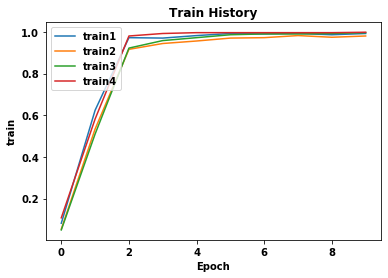

In [47]:
show_train_history(train_history3, 'val_digit1_accuracy', 'val_digit2_accuracy','val_digit3_accuracy', 'val_digit4_accuracy')

In [49]:
filename=input("which file?")
l=[]
for i in range(106):
    x,imacc,facc=Predict_SeriesLabel(model3,filename,i)
    l.append((imacc,facc))
accuracy=np.sum(np.asarray(l),axis=0)
sigma=np.asarray(accuracy)
imgaccuracy=sigma[0]/x.shape[0]
fourwordccuracy=sigma[1]/(4*x.shape[0])
print('%d picture total wrong=%d'%(x.shape[0],4*x.shape[0]-sigma[1]))
print('one word accuracy=',fourwordccuracy)
print('four word accuracy=',imgaccuracy)

which file?owntest


D:\anaconda\lib\site-packages\h5py\_hl\dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


prdict= ['2', '4', 'K', '2']
answer= ['2', '4', 'K', '2']
prdict= ['3', '4', 'F', 'M']
answer= ['3', '4', 'F', 'M']
prdict= ['3', '9', 'Q', 'C']
answer= ['3', '9', 'Q', 'C']
prdict= ['3', 'R', 'C', 'P']
answer= ['3', 'R', 'C', 'P']
prdict= ['3', 'T', 'H', 'H']
answer= ['3', 'T', 'H', 'H']
prdict= ['3', 'Z', '4', 'C']
answer= ['3', 'Z', '4', 'C']
prdict= ['4', '4', 'Y', 'K']
answer= ['4', '4', 'Y', 'K']
prdict= ['4', '9', 'P', 'M']
answer= ['4', '9', 'P', 'M']
prdict= ['4', 'H', 'N', 'K']
answer= ['4', 'H', 'N', 'K']
prdict= ['4', 'M', '3', 'P']
answer= ['4', 'M', '3', 'P']
prdict= ['4', 'M', 'Y', '3']
answer= ['4', 'M', 'Y', '3']
prdict= ['4', 'Y', 'Y', '3']
answer= ['4', 'Y', 'Y', '3']
prdict= ['4', 'Z', '3', 'P']
answer= ['4', 'Z', '3', 'P']
prdict= ['4', 'Z', 'N', 'C']
answer= ['4', 'Z', 'N', 'C']
prdict= ['5', '2', 'Y', 'Q']
answer= ['5', '2', 'Y', 'Q']
prdict= ['5', '4', 'T', 'H']
answer= ['5', '4', 'T', 'H']
prdict= ['5', 'H', 'R', 'Q']
answer= ['5', 'H', 'R', 'Q']
prdict= ['5', 

In [23]:
model4.save('D:/DLmidterm/models/SGD96.h5')

In [103]:
def Nice_Model():
    X_in=Input((48,140,3))
    X=X_in
    X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
    X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Dropout(0.1)(X)
    X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
    X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Dropout(0.1)(X)
    X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
    X=AveragePooling2D(pool_size=(2,2))(X)
    X=Flatten()(X)
    X=[Dense(19, name='digit1', activation='softmax')(X),
                  Dense(19, name='digit2', activation='softmax')(X),
                  Dense(19, name='digit3', activation='softmax')(X),
                  Dense(19, name='digit4', activation='softmax')(X)]
    model=Model(inputs=X_in,outputs=X)
    return model
model5=Nice_Model()
model5.summary()
model5.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
cppath="D:/DLmidterm/checkpoint/SGD-{epoch:02d}-{val_digit2_accuracy:.4f}.h5"
earlystop = EarlyStopping(monitor='val_digit2_accuracy', patience=5, verbose=1, mode='max',min_delta=0.002)
checkpoint= ModelCheckpoint(cppath, monitor='val_digit2_accuracy', verbose=1, save_best_only=False, mode='max')
train_history5=model5.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=20,callbacks=[earlystop,checkpoint])

Model: "model_22"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_22 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_181 (Conv2D)             (None, 48, 140, 8)   1952        input_22[0][0]                   
__________________________________________________________________________________________________
batch_normalization_177 (BatchN (None, 48, 140, 8)   32          conv2d_181[0][0]                 
__________________________________________________________________________________________________
activation_161 (Activation)     (None, 48, 140, 8)   0           batch_normalization_177[0][0]    
___________________________________________________________________________________________

3750/3750 [==============================] - 17s 5ms/step - loss: 0.2661 - digit1_loss: 0.0691 - digit2_loss: 0.0842 - digit3_loss: 0.0722 - digit4_loss: 0.0406 - digit1_accuracy: 0.9899 - digit2_accuracy: 0.9907 - digit3_accuracy: 0.9915 - digit4_accuracy: 0.9976 - val_loss: 1.8675 - val_digit1_loss: 0.4227 - val_digit2_loss: 0.5282 - val_digit3_loss: 0.5044 - val_digit4_loss: 0.4123 - val_digit1_accuracy: 0.9648 - val_digit2_accuracy: 0.9152 - val_digit3_accuracy: 0.9400 - val_digit4_accuracy: 0.9488

Epoch 00004: saving model to D:/DLmidterm/checkpoint/SGD-04-0.9152.h5
Epoch 5/20
3750/3750 [==============================] - 17s 5ms/step - loss: 0.1647 - digit1_loss: 0.0446 - digit2_loss: 0.0512 - digit3_loss: 0.0436 - digit4_loss: 0.0254 - digit1_accuracy: 0.9944 - digit2_accuracy: 0.9955 - digit3_accuracy: 0.9960 - digit4_accuracy: 0.9989 - val_loss: 0.6899 - val_digit1_loss: 0.1707 - val_digit2_loss: 0.2016 - val_digit3_loss: 0.1835 - val_digit4_loss: 0.1342 - val_digit1_accuracy:

In [104]:
model5_1=load_model("D:/DLmidterm/checkpoint/SGD-18-0.9880.h5")


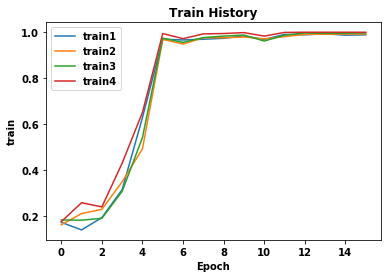

In [79]:
show_train_history(train_history5, 'val_digit1_accuracy', 'val_digit2_accuracy','val_digit3_accuracy', 'val_digit4_accuracy')

In [105]:
filename='owntest'
l=[]
filenum=len(os.listdir('D:/DLmidterm/'+filename+'dealed'))
for i in range(filenum):
    x,imacc,facc=Predict_SeriesLabel(model5_1,filename,i)
    l.append((imacc,facc))
accuracy=np.sum(np.asarray(l),axis=0)
sigma=np.asarray(accuracy)
imgaccuracy=sigma[0]/x.shape[0]
fourwordccuracy=sigma[1]/(4*x.shape[0])
print('%d picture total wrong=%d'%(x.shape[0],4*x.shape[0]-sigma[1]))
print('one word accuracy=',fourwordccuracy)
print('four word accuracy=',imgaccuracy)

D:\anaconda\lib\site-packages\h5py\_hl\dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


number  0
prdict= ['2', '4', 'K', '2']
answer= ['2', '4', 'K', '2']
number  1
prdict= ['2', 'P', 'F', '9']
answer= ['2', 'P', 'F', '9']
number  2
prdict= ['3', '4', 'F', 'M']
answer= ['3', '4', 'F', 'M']
number  3
prdict= ['3', '5', '4', 'T']
answer= ['3', '5', '4', 'T']
number  4
prdict= ['3', '5', 'C', 'Z']
answer= ['3', '5', 'C', 'Z']
number  5
prdict= ['3', '9', 'Q', 'C']
answer= ['3', '9', 'Q', 'C']
number  6
prdict= ['3', 'H', '2', 'C']
answer= ['3', 'H', '2', 'C']
number  7
prdict= ['3', 'R', 'C', 'P']
answer= ['3', 'R', 'C', 'P']
number  8
prdict= ['3', 'T', 'H', 'H']
answer= ['3', 'T', 'H', 'H']
number  9
prdict= ['3', 'Z', '4', 'C']
answer= ['3', 'Z', '4', 'C']
number  10
prdict= ['4', '4', 'Y', 'K']
answer= ['4', '4', 'Y', 'K']
number  11
prdict= ['4', '9', '7', 'K']
answer= ['4', '9', '7', 'K']
number  12
prdict= ['4', '9', 'P', 'M']
answer= ['4', '9', 'P', 'M']
number  13
prdict= ['4', 'A', 'R', 'P']
answer= ['4', 'A', 'R', 'P']
number  14
prdict= ['4', 'H', 'N', 'K']
answ

In [106]:
X_in=Input((48,140,3))
X=X_in
X=Conv2D(filters=8,kernel_size=(3,3),padding='same')(X)
X=Conv2D(filters=8,kernel_size=(3,3),padding='same',activation='relu')(X)
X=BatchNormalization(axis=3)(X)
X=MaxPooling2D((3, 3), strides=(2, 2))(X)
X_shortcut=X
X=Conv2D(filters=32,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=32,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=32,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X_shortcut=Conv2D(filters=32,kernel_size=(1,1),padding='valid')(X_shortcut)
X_shortcut=BatchNormalization(axis=3)(X_shortcut)
X = Add()([X,X_shortcut])
X = Activation('relu')(X)
X = Dropout(0.2)(X)
X_shortcut=X
X=Conv2D(filters=64,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=64,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X_shortcut=Conv2D(filters=64,kernel_size=(1,1),padding='valid')(X_shortcut)
X_shortcut=BatchNormalization(axis=3)(X_shortcut)
X = Add()([X,X_shortcut])
X = Activation('relu')(X)
X = Dropout(0.2)(X)
X_shortcut=X
X=Conv2D(filters=128,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X_shortcut=Conv2D(filters=128,kernel_size=(1,1),padding='valid')(X_shortcut)
X_shortcut=BatchNormalization(axis=3)(X_shortcut)
X = Add()([X,X_shortcut])
X = Activation('relu')(X)
X_shortcut=X
X=Conv2D(filters=256,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X_shortcut=Conv2D(filters=256,kernel_size=(1,1),padding='valid')(X_shortcut)
X_shortcut=BatchNormalization(axis=3)(X_shortcut)
X = Add()([X,X_shortcut])
X = Activation('relu')(X)
X_shortcut=X
X=Conv2D(filters=512,kernel_size=(1,1),padding='valid')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X=Conv2D(filters=512,kernel_size=(3,3),padding='same')(X)
X=BatchNormalization(axis=3)(X)
X = Activation('relu')(X)
X_shortcut=Conv2D(filters=512,kernel_size=(1,1),padding='valid')(X_shortcut)
X_shortcut=BatchNormalization(axis=3)(X_shortcut)
X = Add()([X,X_shortcut])
X = Activation('relu')(X)
X=AveragePooling2D(pool_size=(2,2))(X)
X=Flatten()(X)
X=[Dense(19, name='digit1', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.02))(X),
              Dense(19, name='digit2', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.02))(X),
              Dense(19, name='digit3', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.02))(X),
              Dense(19, name='digit4', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.02))(X)]
model6=Model(inputs=X_in,outputs=X)
model6.summary()
model6.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
earlystop = EarlyStopping(monitor='val_digit2_accuracy', patience=3, verbose=1, mode='auto')
cppath="D:/DLmidterm/checkpoint/Resmodel-{epoch:02d}-{val_digit2_accuracy:.2f}.h5"
checkpoint= ModelCheckpoint(cppath, monitor='val_digit2_accuracy', verbose=1, save_best_only=False, mode='max')
train_history6=model6.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=50, epochs=40,callbacks=[earlystop,checkpoint])

Model: "model_23"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_23 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_187 (Conv2D)             (None, 48, 140, 8)   224         input_23[0][0]                   
__________________________________________________________________________________________________
conv2d_188 (Conv2D)             (None, 48, 140, 8)   584         conv2d_187[0][0]                 
__________________________________________________________________________________________________
batch_normalization_183 (BatchN (None, 48, 140, 8)   32          conv2d_188[0][0]                 
___________________________________________________________________________________________

Train on 3750 samples, validate on 1250 samples
Epoch 1/40


ResourceExhaustedError:  OOM when allocating tensor with shape[50,512,23,69] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc
	 [[{{node gradients_36/batch_normalization_199/cond_grad/StatelessIf/then/_385/zeros_like_0}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info.
 [Op:__inference_keras_scratch_graph_624553]

Function call stack:
keras_scratch_graph


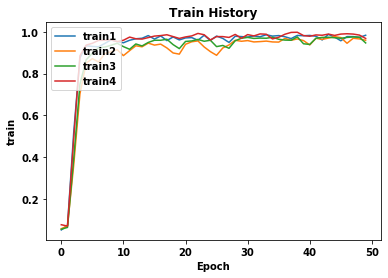

In [39]:
show_train_history(train_history5, 'val_digit1_accuracy', 'val_digit2_accuracy','val_digit3_accuracy', 'val_digit4_accuracy')

In [40]:
filename=input("which file?")
l=[]
for i in range(106):
    x,imacc,facc=Predict_SeriesLabel(model5,filename,i)
    l.append((imacc,facc))
accuracy=np.sum(np.asarray(l),axis=0)
sigma=np.asarray(accuracy)
imgaccuracy=sigma[0]/x.shape[0]
fourwordccuracy=sigma[1]/(4*x.shape[0])
print('%d picture total wrong=%d'%(x.shape[0],4*x.shape[0]-sigma[1]))
print('one word accuracy=',fourwordccuracy)
print('four word accuracy=',imgaccuracy)

which file?owntest


D:\anaconda\lib\site-packages\h5py\_hl\dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


number  0
prdict= ['2', '4', 'K', '2']
answer= ['2', '4', 'K', '2']
number  1
prdict= ['3', 'H', 'F', 'M']
answer= ['3', '4', 'F', 'M']
number  2
prdict= ['3', '9', 'Q', 'C']
answer= ['3', '9', 'Q', 'C']
number  3
prdict= ['3', 'R', 'C', 'P']
answer= ['3', 'R', 'C', 'P']
number  4
prdict= ['3', 'T', 'H', 'H']
answer= ['3', 'T', 'H', 'H']
number  5
prdict= ['3', 'Z', '4', 'C']
answer= ['3', 'Z', '4', 'C']
number  6
prdict= ['4', '4', 'Y', 'K']
answer= ['4', '4', 'Y', 'K']
number  7
prdict= ['4', '9', 'P', 'M']
answer= ['4', '9', 'P', 'M']
number  8
prdict= ['4', 'H', 'N', 'K']
answer= ['4', 'H', 'N', 'K']
number  9
prdict= ['4', 'M', 'T', 'P']
answer= ['4', 'M', '3', 'P']
number  10
prdict= ['4', 'M', 'Y', '3']
answer= ['4', 'M', 'Y', '3']
number  11
prdict= ['4', 'Y', 'Y', '3']
answer= ['4', 'Y', 'Y', '3']
number  12
prdict= ['4', 'Z', '3', 'P']
answer= ['4', 'Z', '3', 'P']
number  13
prdict= ['4', 'Z', 'N', 'C']
answer= ['4', 'Z', 'N', 'C']
number  14
prdict= ['5', '2', 'Y', 'P']
answ

In [ ]:
import multiprocess as mp
import numpy as np


if __name__=='__main__':
    # Get all worker processes
    cores = mp.cpu_count()

    # Start all worker processes
    pool = mp.Pool(processes=cores)
    filename=input("which file?")
    tasks = [(model,filename,i) for i in range(10)]
    res=pool.starmap(Predict_SeriesLabel,tasks)
    accuracy=np.sum(np.asarray(tasks),axis=0)
    sigma=np.asarray(accuracy)
    imgaccuracy=sigma[0]/x.shape[1]
    fourwordccuracy=sigma[1]/x.shape[1]
    print('imgaccuracy=',imgaccuracy)
    print('fourwordccuracy=',fourwordccuracy)

which file?owntest


In [5]:

def Model1():
    X_in=Input((48,140,3))
    X=X_in
    X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
    X=Conv2D(filters=8,kernel_size=(9,9),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
    X=Conv2D(filters=16,kernel_size=(9,9),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
    X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
    X=Conv2D(filters=32,kernel_size=(9,9),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
    X=Conv2D(filters=64,kernel_size=(3,3),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Dropout(0.2)(X)
    X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
    X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
    X=Conv2D(filters=128,kernel_size=(3,3),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
    X=Conv2D(filters=256,kernel_size=(3,3),padding='same')(X)
    X=BatchNormalization(axis=3)(X)
    X=Activation('relu')(X)
    X=Dropout(0.2)(X)
    X=MaxPooling2D(pool_size=(3, 3),strides=(2,2))(X)
    X=AveragePooling2D(pool_size=(2,2))(X)
    X=Flatten()(X)
    X=[Dense(19, name='digit1', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.03))(X),
                  Dense(19, name='digit2', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.03))(X),
                  Dense(19, name='digit3', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.03))(X),
                  Dense(19, name='digit4', activation='softmax',kernel_regularizer=keras.regularizers.l2(0.03))(X)]
    model=Model(inputs=X_in,outputs=X)
    return model


In [ ]:
model5=Model1()
model5.summary()
model5.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
cppath="D:/DLmidterm/checkpoint/sgd-{epoch:02d}-{val_digit2_accuracy:.4f}.h5"
earlystop = EarlyStopping(monitor='val_digit2_accuracy', patience=5, verbose=1, mode='max',min_delta=0.002)
checkpoint= ModelCheckpoint(cppath, monitor='val_digit2_accuracy', verbose=1, save_best_only=False, mode='max')
train_history5=model5.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=100, epochs=50,callbacks=[earlystop,checkpoint])

In [155]:
model6=Model1()
model6.summary()
model6.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
cppath="D:/DLmidterm/checkpoint/Adam-{epoch:02d}-{val_digit2_accuracy:.4f}.h5"
earlystop = EarlyStopping(monitor='val_digit2_accuracy', patience=5, verbose=1, mode='max',min_delta=0.002)
checkpoint= ModelCheckpoint(cppath, monitor='val_digit2_accuracy', verbose=1, save_best_only=False, mode='max')
train_history6=model6.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=100, epochs=50,callbacks=[earlystop,checkpoint])

Model: "model_37"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_37 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_362 (Conv2D)             (None, 48, 140, 8)   1952        input_37[0][0]                   
__________________________________________________________________________________________________
conv2d_363 (Conv2D)             (None, 48, 140, 8)   5192        conv2d_362[0][0]                 
__________________________________________________________________________________________________
batch_normalization_279 (BatchN (None, 48, 140, 8)   32          conv2d_363[0][0]                 
___________________________________________________________________________________________


Epoch 00001: saving model to D:/DLmidterm/checkpoint/Adam-01-0.0904.h5
Epoch 2/50
3750/3750 [==============================] - 16s 4ms/step - loss: 10.0078 - digit1_loss: 1.6061 - digit2_loss: 1.6418 - digit3_loss: 1.6181 - digit4_loss: 1.3665 - digit1_accuracy: 0.4731 - digit2_accuracy: 0.4640 - digit3_accuracy: 0.4632 - digit4_accuracy: 0.5424 - val_loss: 19.4594 - val_digit1_loss: 4.9015 - val_digit2_loss: 4.1868 - val_digit3_loss: 3.8595 - val_digit4_loss: 3.0558 - val_digit1_accuracy: 0.2256 - val_digit2_accuracy: 0.1872 - val_digit3_accuracy: 0.1536 - val_digit4_accuracy: 0.2184

Epoch 00002: saving model to D:/DLmidterm/checkpoint/Adam-02-0.1872.h5
Epoch 3/50
3750/3750 [==============================] - 16s 4ms/step - loss: 5.4048 - digit1_loss: 0.4732 - digit2_loss: 0.6359 - digit3_loss: 0.6043 - digit4_loss: 0.4437 - digit1_accuracy: 0.8464 - digit2_accuracy: 0.7891 - digit3_accuracy: 0.8059 - digit4_accuracy: 0.8635 - val_loss: 12.7315 - val_digit1_loss: 3.1565 - val_digit2_


Epoch 00015: saving model to D:/DLmidterm/checkpoint/Adam-15-0.9568.h5
Epoch 16/50
3750/3750 [==============================] - 16s 4ms/step - loss: 0.3367 - digit1_loss: 0.0158 - digit2_loss: 0.0116 - digit3_loss: 0.0138 - digit4_loss: 0.0134 - digit1_accuracy: 0.9971 - digit2_accuracy: 0.9989 - digit3_accuracy: 0.9981 - digit4_accuracy: 0.9984 - val_loss: 1.7275 - val_digit1_loss: 0.5176 - val_digit2_loss: 0.3745 - val_digit3_loss: 0.3095 - val_digit4_loss: 0.2897 - val_digit1_accuracy: 0.9096 - val_digit2_accuracy: 0.9240 - val_digit3_accuracy: 0.9656 - val_digit4_accuracy: 0.9672

Epoch 00016: saving model to D:/DLmidterm/checkpoint/Adam-16-0.9240.h5
Epoch 17/50
3750/3750 [==============================] - 16s 4ms/step - loss: 0.3360 - digit1_loss: 0.0420 - digit2_loss: 0.0213 - digit3_loss: 0.0182 - digit4_loss: 0.0092 - digit1_accuracy: 0.9899 - digit2_accuracy: 0.9955 - digit3_accuracy: 0.9981 - digit4_accuracy: 0.9992 - val_loss: 1.9295 - val_digit1_loss: 0.3687 - val_digit2_l

In [156]:
##AdamAdamax-10-0.9920
model7=Model1()
model7.summary()
model7.compile(loss='categorical_crossentropy', optimizer='Adamax', metrics=['accuracy'])
cppath="D:/DLmidterm/checkpoint/Adamax-{epoch:02d}-{val_digit2_accuracy:.4f}.h5"
earlystop = EarlyStopping(monitor='val_digit2_accuracy', patience=5, verbose=1, mode='max',min_delta=0.002)
checkpoint= ModelCheckpoint(cppath, monitor='val_digit2_accuracy', verbose=1, save_best_only=False, mode='max')
train_history7=model7.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=100, epochs=50,callbacks=[earlystop,checkpoint])

Model: "model_38"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_38 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_374 (Conv2D)             (None, 48, 140, 8)   1952        input_38[0][0]                   
__________________________________________________________________________________________________
conv2d_375 (Conv2D)             (None, 48, 140, 8)   5192        conv2d_374[0][0]                 
__________________________________________________________________________________________________
batch_normalization_285 (BatchN (None, 48, 140, 8)   32          conv2d_375[0][0]                 
___________________________________________________________________________________________


Epoch 00001: saving model to D:/DLmidterm/checkpoint/Adamax-01-0.0464.h5
Epoch 2/50
3750/3750 [==============================] - 16s 4ms/step - loss: 13.7144 - digit1_loss: 2.3524 - digit2_loss: 2.6316 - digit3_loss: 2.4972 - digit4_loss: 2.2539 - digit1_accuracy: 0.2512 - digit2_accuracy: 0.1837 - digit3_accuracy: 0.1981 - digit4_accuracy: 0.2624 - val_loss: 47.5534 - val_digit1_loss: 12.2125 - val_digit2_loss: 11.9764 - val_digit3_loss: 7.7855 - val_digit4_loss: 11.8474 - val_digit1_accuracy: 0.0608 - val_digit2_accuracy: 0.0616 - val_digit3_accuracy: 0.0768 - val_digit4_accuracy: 0.0464

Epoch 00002: saving model to D:/DLmidterm/checkpoint/Adamax-02-0.0616.h5
Epoch 3/50
3750/3750 [==============================] - 16s 4ms/step - loss: 11.0269 - digit1_loss: 1.6634 - digit2_loss: 2.1135 - digit3_loss: 2.0296 - digit4_loss: 1.5955 - digit1_accuracy: 0.4600 - digit2_accuracy: 0.2979 - digit3_accuracy: 0.3104 - digit4_accuracy: 0.4744 - val_loss: 14.5144 - val_digit1_loss: 3.0673 - val


Epoch 00015: saving model to D:/DLmidterm/checkpoint/Adamax-15-0.7600.h5
Epoch 16/50
3750/3750 [==============================] - 16s 4ms/step - loss: 1.3228 - digit1_loss: 0.0205 - digit2_loss: 0.0225 - digit3_loss: 0.0191 - digit4_loss: 0.0121 - digit1_accuracy: 0.9971 - digit2_accuracy: 0.9984 - digit3_accuracy: 0.9989 - digit4_accuracy: 0.9995 - val_loss: 4.2553 - val_digit1_loss: 0.7119 - val_digit2_loss: 0.8339 - val_digit3_loss: 0.8679 - val_digit4_loss: 0.6474 - val_digit1_accuracy: 0.8264 - val_digit2_accuracy: 0.7616 - val_digit3_accuracy: 0.7728 - val_digit4_accuracy: 0.8280

Epoch 00016: saving model to D:/DLmidterm/checkpoint/Adamax-16-0.7616.h5
Epoch 17/50
3750/3750 [==============================] - 16s 4ms/step - loss: 1.2064 - digit1_loss: 0.0167 - digit2_loss: 0.0186 - digit3_loss: 0.0182 - digit4_loss: 0.0106 - digit1_accuracy: 0.9976 - digit2_accuracy: 0.9987 - digit3_accuracy: 0.9987 - digit4_accuracy: 0.9995 - val_loss: 3.3936 - val_digit1_loss: 0.5719 - val_digi


Epoch 00029: saving model to D:/DLmidterm/checkpoint/Adamax-29-0.9864.h5
Epoch 30/50
3750/3750 [==============================] - 16s 4ms/step - loss: 0.4222 - digit1_loss: 0.0118 - digit2_loss: 0.0090 - digit3_loss: 0.0097 - digit4_loss: 0.0067 - digit1_accuracy: 0.9979 - digit2_accuracy: 1.0000 - digit3_accuracy: 0.9995 - digit4_accuracy: 1.0000 - val_loss: 0.9326 - val_digit1_loss: 0.1484 - val_digit2_loss: 0.1598 - val_digit3_loss: 0.1440 - val_digit4_loss: 0.1131 - val_digit1_accuracy: 0.9872 - val_digit2_accuracy: 0.9904 - val_digit3_accuracy: 0.9952 - val_digit4_accuracy: 0.9992

Epoch 00030: saving model to D:/DLmidterm/checkpoint/Adamax-30-0.9904.h5
Epoch 31/50
3750/3750 [==============================] - 16s 4ms/step - loss: 0.3921 - digit1_loss: 0.0107 - digit2_loss: 0.0107 - digit3_loss: 0.0086 - digit4_loss: 0.0059 - digit1_accuracy: 0.9981 - digit2_accuracy: 0.9989 - digit3_accuracy: 0.9997 - digit4_accuracy: 1.0000 - val_loss: 1.6550 - val_digit1_loss: 0.3405 - val_digi

In [23]:
model8=Model1()
model8.summary()
model8.compile(loss='categorical_crossentropy', optimizer='RMSprop', metrics=['accuracy'])
#cppath="D:/DLmidterm/checkpoint/RMSprop-{epoch:02d}-{val_digit2_accuracy:.4f}.h5"
#earlystop = EarlyStopping(monitor='val_digit2_accuracy', patience=5, verbose=1, mode='max',min_delta=0.002)
#checkpoint= ModelCheckpoint(cppath, monitor='val_digit2_accuracy', verbose=1, save_best_only=False, mode='max')
train_history8=model8.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=25, epochs=15)#,callbacks=[earlystop,checkpoint]

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_49 (Conv2D)              (None, 48, 140, 8)   1952        input_5[0][0]                    
__________________________________________________________________________________________________
conv2d_50 (Conv2D)              (None, 48, 140, 8)   5192        conv2d_49[0][0]                  
__________________________________________________________________________________________________
batch_normalization_25 (BatchNo (None, 48, 140, 8)   32          conv2d_50[0][0]                  
____________________________________________________________________________________________

Epoch 2/15
3750/3750 [==============================] - 20s 5ms/step - loss: 4.5391 - digit1_loss: 0.7007 - digit2_loss: 1.0504 - digit3_loss: 1.0192 - digit4_loss: 0.6691 - digit1_accuracy: 0.7664 - digit2_accuracy: 0.6416 - digit3_accuracy: 0.6595 - digit4_accuracy: 0.7773 - val_loss: 12.6069 - val_digit1_loss: 3.7389 - val_digit2_loss: 2.8013 - val_digit3_loss: 2.4531 - val_digit4_loss: 2.5405 - val_digit1_accuracy: 0.3016 - val_digit2_accuracy: 0.3608 - val_digit3_accuracy: 0.4496 - val_digit4_accuracy: 0.4680
Epoch 3/15
3750/3750 [==============================] - 20s 5ms/step - loss: 1.9912 - digit1_loss: 0.2210 - digit2_loss: 0.3340 - digit3_loss: 0.3401 - digit4_loss: 0.1729 - digit1_accuracy: 0.9371 - digit2_accuracy: 0.8981 - digit3_accuracy: 0.8960 - digit4_accuracy: 0.9541 - val_loss: 1.6378 - val_digit1_loss: 0.1434 - val_digit2_loss: 0.3395 - val_digit3_loss: 0.2751 - val_digit4_loss: 0.1125 - val_digit1_accuracy: 0.9768 - val_digit2_accuracy: 0.8976 - val_digit3_accuracy

In [9]:
TestOwn()


which modelRMSprop-11-0.9952


IndexError: too many indices for array

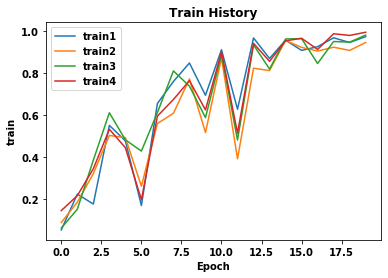

In [158]:
show_train_history(train_history6, 'val_digit1_accuracy', 'val_digit2_accuracy','val_digit3_accuracy', 'val_digit4_accuracy')

In [15]:
modelgg=load_model("D:/DLmidterm/checkpoint/Adamax-10-0.9920.h5")
modelgg.summary()

Model: "model_33"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_33 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_314 (Conv2D)             (None, 48, 140, 8)   1952        input_33[0][0]                   
__________________________________________________________________________________________________
conv2d_315 (Conv2D)             (None, 48, 140, 8)   5192        conv2d_314[0][0]                 
__________________________________________________________________________________________________
batch_normalization_255 (BatchN (None, 48, 140, 8)   32          conv2d_315[0][0]                 
___________________________________________________________________________________________

In [13]:
modelgg1=load_model("D:/DLmidterm/checkpoint/Adamax-18-0.9920.h5")
modelgg1.summary()

Model: "model_26"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_26 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_230 (Conv2D)             (None, 48, 140, 8)   1952        input_26[0][0]                   
__________________________________________________________________________________________________
conv2d_231 (Conv2D)             (None, 48, 140, 8)   5192        conv2d_230[0][0]                 
__________________________________________________________________________________________________
batch_normalization_213 (BatchN (None, 48, 140, 8)   32          conv2d_231[0][0]                 
___________________________________________________________________________________________

In [14]:
modelgg2=load_model("D:/DLmidterm/checkpoint/RMSprop-11-0.9952.h5")
modelgg2.summary()

Model: "model_34"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_34 (InputLayer)           (None, 48, 140, 3)   0                                            
__________________________________________________________________________________________________
conv2d_326 (Conv2D)             (None, 48, 140, 8)   1952        input_34[0][0]                   
__________________________________________________________________________________________________
conv2d_327 (Conv2D)             (None, 48, 140, 8)   5192        conv2d_326[0][0]                 
__________________________________________________________________________________________________
batch_normalization_261 (BatchN (None, 48, 140, 8)   32          conv2d_327[0][0]                 
___________________________________________________________________________________________

In [22]:
modelgg2.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size=100, epochs=1)

Train on 3750 samples, validate on 1250 samples
Epoch 1/1
3750/3750 [==============================] - 13s 3ms/step - loss: 0.1728 - digit1_loss: 0.0255 - digit2_loss: 0.0196 - digit3_loss: 0.0158 - digit4_loss: 0.0120 - digit1_accuracy: 0.9941 - digit2_accuracy: 0.9971 - digit3_accuracy: 0.9971 - digit4_accuracy: 0.9984 - val_loss: 0.5393 - val_digit1_loss: 0.0921 - val_digit2_loss: 0.1374 - val_digit3_loss: 0.1249 - val_digit4_loss: 0.0825 - val_digit1_accuracy: 0.9904 - val_digit2_accuracy: 0.9864 - val_digit3_accuracy: 0.9952 - val_digit4_accuracy: 0.9992
